# Labb 2
## EDA

### nödvändiga moduler :
pandas: för databehandling i tabellform osv.

matplotlib: för att plotta grafer.

seaborn: för avancerade grafer.

scipy.sparse: hantering av matriser för mindre plats.

sklearn.neighbors: för KNN.

fuzzywuzzy: för att jämföra texter och kunna hitta filmtitlar, trots felstavning.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from fuzzywuzzy import process

c:\source\UE_ML_AI24\.venv\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


### Läsa in CSV filer med Pandas

In [3]:
df_movies = pd.read_csv("movies.csv")
df_ratings = pd.read_csv("ratings.csv")

In [4]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


### funktionen som returnerar titel ifrån filmer

In [6]:
def movie_titles(id):
    return df_movies.query("movieId == @id")["title"].item()

In [7]:
movie_titles(15)

'Cutthroat Island (1995)'

### Filmer med högst ratings
variabel som innehåller top 10 filmer med mest betyg

In [8]:
most_rated_10 = df_ratings["movieId"].value_counts()[:10]
most_rated_10

movieId
318     122296
356     113581
296     108756
2571    107056
593     101802
260      97202
2959     86207
527      84232
480      83026
1196     80200
Name: count, dtype: int64

### 

In [9]:
most_rated_10_titles = []
for id_of_movies in most_rated_10.index:
    most_rated_10_titles.insert(0, movie_titles(id_of_movies))

### top 10 betygsatta filmer sparade med titlar

In [10]:
most_rated_10_titles

['Star Wars: Episode V - The Empire Strikes Back (1980)',
 'Jurassic Park (1993)',
 "Schindler's List (1993)",
 'Fight Club (1999)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Silence of the Lambs, The (1991)',
 'Matrix, The (1999)',
 'Pulp Fiction (1994)',
 'Forrest Gump (1994)',
 'Shawshank Redemption, The (1994)']

### Barplot som visar betygsättning på top 10 filmer

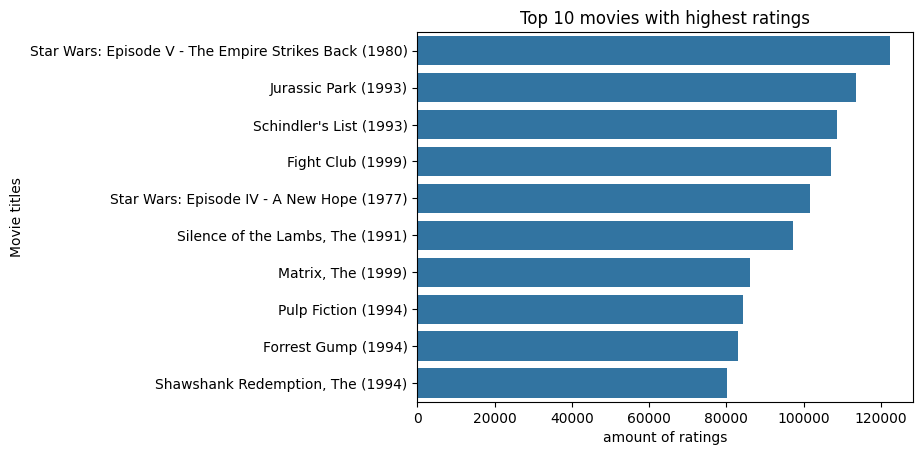

In [11]:
ax = sns.barplot(x=most_rated_10, y=most_rated_10_titles)
ax.set(xlabel="amount of ratings", ylabel="Movie titles", title="Top 10 movies with highest ratings")
plt.show()

### Medelvärde på poängen av top 10 högst betygsatta filmer

In [12]:
most_rated_10_mean = df_ratings[df_ratings["movieId"].isin(most_rated_10.index)]["rating"].mean()
print(f"Mean of top 10 highest rated movies: {most_rated_10_mean:.1f} of 5")

Mean of top 10 highest rated movies: 4.1 of 5


### En kolumn i movies dataframe döpt till "year" som visar årtal

In [13]:
df_movies["year"] = df_movies["title"].str[-5:-1]

df_movies.tail()

,movieId,title,genres,year
86532,288967,State of Siege: Temple Attack (2021),Action|Drama,2021
86533,288971,Ouija Japan (2021),Action|Horror,2021
86534,288975,The Men Who Made the Movies: Howard Hawks (1973),Documentary,1973
86535,288977,Skinford: Death Sentence (2023),Crime|Thriller,2023
86536,288983,UNZIPPED: An Autopsy of American Inequality (2...,Documentary,2021


### Barplot som visar antal filmer som hade premiär under vissa specifika år som sedan väljer ut top 10 filmer som hade flest premiär

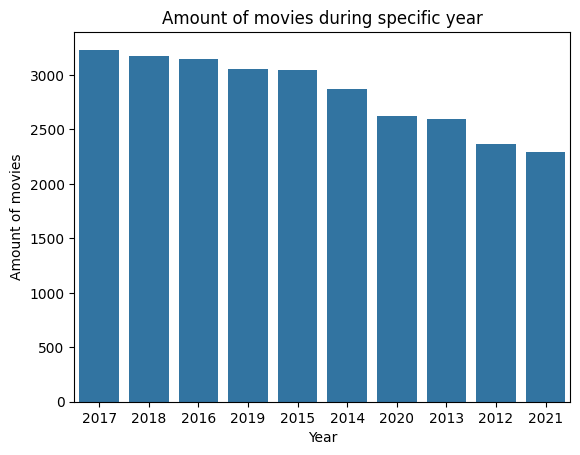

In [14]:
released_movies_year = df_movies["year"].value_counts()[:10]

ax = sns.barplot(y = released_movies_year, x = released_movies_year.index)
ax.set(xlabel = "Year", ylabel = "Amount of movies", title = "Amount of movies during specific year")
plt.show()

## Sparse matrix

### Visar antal rader inom df_ratings

In [15]:
ratings_amount = df_ratings.shape[0]
ratings_amount

33832162

### Antal filmer som finns i df_ratings

In [16]:
movies_amount = df_ratings["movieId"].nunique()
movies_amount

83239

In [17]:
print(f"There is total amount of {ratings_amount:,} ratings for {movies_amount:,} movies".replace(",", " "))

There is total amount of 33 832 162 ratings for 83 239 movies


### Räknar ut antal gånger av varje movieID som förekommer gällande hur mycket filmerna har fått i betyg

In [18]:
count_of_ratings = df_ratings["movieId"].value_counts()
count_of_ratings

movieId
318       122296
356       113581
296       108756
2571      107056
593       101802
           ...  
212773         1
194901         1
194572         1
194002         1
193301         1
Name: count, Length: 83239, dtype: int64

### En serie av filmer som har mindre än 5000 i betygsättning och en serie och dataframe med 5000 eller högre i betygsättning

In [19]:
ratings_less_5000 = count_of_ratings[count_of_ratings < 5000]
ratings_higher_5000 = count_of_ratings[count_of_ratings >= 5000]
ratings_higher_5000_movies = df_ratings[df_ratings["movieId"].isin(ratings_higher_5000.index)]

In [20]:
ratings_less_5000

movieId
1678      4995
1956      4995
1672      4990
7371      4989
707       4984
          ... 
212773       1
194901       1
194572       1
194002       1
193301       1
Name: count, Length: 81680, dtype: int64

In [21]:
ratings_higher_5000

movieId
318      122296
356      113581
296      108756
2571     107056
593      101802
          ...  
3355       5035
3089       5034
1224       5027
63859      5017
1359       5007
Name: count, Length: 1559, dtype: int64

In [22]:
ratings_higher_5000_movies

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119
...,...,...,...,...
33832149,330975,6874,4.0,1091684274
33832155,330975,7153,4.0,1091582733
33832159,330975,8622,4.0,1091581777
33832160,330975,8665,3.0,1091581765


In [23]:
ratings_less_5000.sum()

np.int64(10058619)

In [24]:
print(f"Percentage of removed data: {ratings_less_5000.sum() / ratings_amount * 100:.1f}%")

Percentage of removed data: 29.7%


In [25]:
print(f"Percentage of remaining data: {len(ratings_higher_5000_movies) / ratings_amount * 100:.1f}%")

Percentage of remaining data: 70.3%


In [26]:
print(f"Percentage of movies less than 5000 ratings {len(ratings_less_5000)/movies_amount * 100:.1f}%")

Percentage of movies less than 5000 ratings 98.1%


### Nu när remaining data är 70,3 % av all data, så representeras ungefär 1,9 % av de mest populäraste filmerna, då är det dags att skapa en sparse matrix
Först behövs datan göras om så att varje rad motsvarar en film och varje kolumn en användare, och cellerna innehåller användarens betyg. Ifall ett betyg saknas, då blir det lika med 0 i kolumnen.
Anledningen till att det bara blir cirka 1,9 % av filmerna är simpel. Många människor är upptagna med vardagliga sysslor och prioriterar att se just de populäraste filmerna när de väl har fritid.

In [27]:
users_request_movies = ratings_higher_5000_movies.pivot(index="movieId", columns="userId", values="rating").fillna(0)


### En sparse matrix av pivot tabellen för att kunna spara minne och effektivisera KNN-beräkningar

In [28]:
users_request_movies_matrix = csr_matrix(users_request_movies.values)
users_request_movies_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23773543 stored elements and shape (1559, 328723)>

### Rekommendationssystem behövs byggas med KNN
En filtrerad lista måste utföras med de filmer som är kvar efter att vi har sorterat bort de mindre populära filmerna

In [29]:
recommended_movies = df_movies[df_movies["movieId"].isin(ratings_higher_5000_movies["movieId"].unique())].reset_index()
recommended_movies

,index,movieId,title,genres,year
0,0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,5,Father of the Bride Part II (1995),Comedy,1995
4,5,6,Heat (1995),Action|Crime|Thriller,1995
...,...,...,...,...,...
1554,62208,204698,Joker (2019),Crime|Drama|Thriller,2019
1555,62414,205156,Jojo Rabbit (2019),Comedy|War,2019
1556,63316,207313,Knives Out (2019),Comedy|Crime|Drama|Mystery|Thriller,2019
1557,63916,208703,1917 (2019),Drama|War,2019


### KNN-modellen tränas på vår sparse matrix

Antalet nearest neighbors sätts till 20 för att kunna hitta de 20 mest liknande filmerna

"cosine" används som mått för att kunna upptäcka hur lika betygsmönstren är

"brute" används för att den jämföra varje film med de andra filmerna för bästa möjliga matchning mellan filmerna

In [30]:
KNN_algorithm = NearestNeighbors(n_neighbors = 20, metric = "cosine", algorithm = "brute")
KNN_algorithm.fit(users_request_movies_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=20)

### funktionen som låter användare och söka efter en specifik filmtitel eller filmtitlar anropas
Fem liknande filmer dyker upp som rekommendation, utifrån den titeln som användaren söker

### Funktionen låter användaren söka efter en filmtitel för att få liknande rekommendationer
Funktionen använder information ifrån df med rekommenderbara filmer, filmtitlar, KNN-modellen och sparse matrix.
Med hjälp av fuzzywuzzy hittar vi de sex närmaste och liknande matchningarna, det blir sex istället för fem då själva filmen som användaren har sökt efter är med i listan
Sedan dyker de fem mest liknande/matchande filmerna som rekommendation

In [31]:

def movies_recommendations():
    try: 
        user_input = input("Write the exact title of the movie: ")
        match = process.extractOne(user_input, recommended_movies["title"], score_cutoff=90)
        index = match[2]
        
        _ , indices = KNN_algorithm.kneighbors(users_request_movies_matrix[index], n_neighbors = 6)

        print(f"Top 5 recommendations: {recommended_movies['title'].iloc[indices[0][0]]}")
        
        for neighbor_index in indices[0][1:]:
            print(recommended_movies["title"].iloc[neighbor_index])
    
    except (TypeError, IndexError):
                
                print(f"Sorry! Could not find movie title '{user_input}' in the database.")
                return

  

In [33]:
movies_recommendations()

Top 5 recommendations: Deadpool (2016)
Guardians of the Galaxy (2014)
The Martian (2015)
Doctor Strange (2016)
Kingsman: The Secret Service (2015)
Guardians of the Galaxy 2 (2017)


Rekommendationssystemet använder KNN för att hitta filmer som liknar eller matchar med varandra, utifrån betygsättningar som filmerna har fått.
Byggs på metoden som kallas collaborative filtering. Metoden utgår ifrån beroende på om flera användare har satt liknande betyg på liknande filmer, då är det med högst sannolikhet att de filmerna är ganska liknande intressemässigt. Därför kan filmer med liknande innehåll rekommenderas, utifrån vad andra med liknande intresse av film har betygsatt.

Algoritmen som denna fungerar jättebra för användare som har satt flera betyg, eller gällande filmer som har fått väldigt många betyg. Dock så fungerar det sämre för nya användare eller filmer med mycket mindre data.

Content-based filtering är en annan metod, som istället fokuserar på filmens egenskaper såsom genre, skådespelare och teman.
Systemet i Content-based filtering lär sig just den typen av filmer som användaren gillar, baserad på tidigare val av filmer.
Eftersom systemet utgår ifrån innehållet, kan även nya användare få bra liknande rekommendationer, särskilt om systemet har tillgång till en viss information om användaren, som t.ex. ålder, kön, geografisk område, språk osv.